# Image processing using the heat equation
This notebook explores image smoothing using partial differential equations, focusing on the heat equation and its application to isotropic and anisotropic diffusion in image processing.

Isotropic diffusion models image smoothing as a uniform heat flow, reducing noise but also blurring edges. In contrast, anisotropic diffusion adapts the diffusion process based on image gradients, allowing noise reduction while better preserving important edge structures.

The goal of this project is to:

- Implement the heat equation for isotropic diffusion

- Implement anisotropic diffusion with gradient-dependent diffusion coefficients

- Compare their effects on noise removal and edge preservation

- Visualize how diffusion evolves over time

All methods are implemented numerically and applied to grayscale images to illustrate the strengths and limitations of each approach.

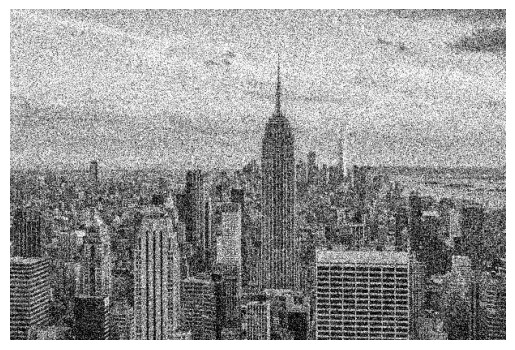

In [52]:
#Importing libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Import image here, adding to same folder
img = cv2.imread("city_skyline.JPG", cv2.IMREAD_GRAYSCALE)
img = img.astype(np.float32) / 255.0

#Adding random noise
noise = 0.2 * np.random.randn(*img.shape)
noisy_img = np.clip(img + noise, 0, 1)

if img is None:
    print("Image not found!")
else:
    #Printing the noisy image
    noisy_img = noisy_img.astype(np.float32) / 255.0
    plt.imshow(noisy_img, cmap="gray")
    plt.axis("off")

# Isotropic diffusion
Just like heat flow, isotropic diffusion spreads image pixel intensities from high to low values.
We model this with the heat equation:
\begin{align}
  \frac{\partial I}{\partial t} = \nabla ^2 I,
\end{align}
where $I$ is the image intensity, $t$ is the diffusion time, and $\nabla ^2$ is the Laplacian operator.

This process helps to reduce random noise and smooth flat regions in an image. However, it also blurs the edges and fine details may be lost over time.

In [53]:
#Laplacian diffusion: Isotropic.

#Defining a function to apply isotropic diffusion
def diffuse(img, lam=0.2, iterations=50):
    I = img.copy()

    for _ in range(iterations):
      #Estimating the derivative using finite differences.
        laplacian = (
            np.roll(I, 1, axis=0) +  #shifts row pixels to right
            np.roll(I, -1, axis=0) + #shifts row pixels to left
            np.roll(I, 1, axis=1) +  #shifts col pixels to right
            np.roll(I, -1, axis=1) - #shifts col pixels to left
            4 * I)

        I = I + lam * laplacian

    return I

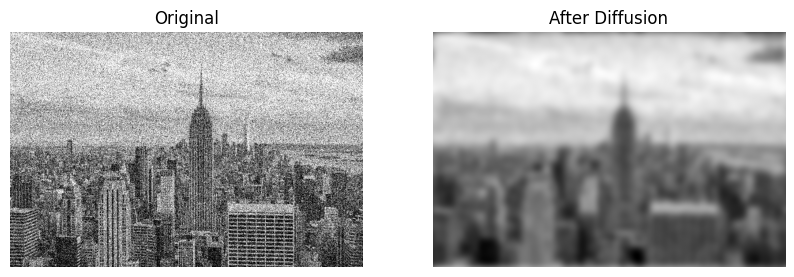

In [54]:
#Applying smoothing to image
smoothed = diffuse(noisy_img, lam=0.2, iterations=100)

#Creating figure
plt.figure(figsize=(10,4))

#Adding noisy image
plt.subplot(1,2,1)
plt.imshow(noisy_img, cmap="gray")
plt.title("Original")
plt.axis("off")

#Adding smoothed image
plt.subplot(1,2,2)
plt.imshow(smoothed, cmap="gray")
plt.title("After Diffusion")
plt.axis("off")

plt.show()


### Visualising isotropic diffusion
This time, we repeat the process but produce an image at each iteration. This will visualise the prodcedure gradually smoothing our image.

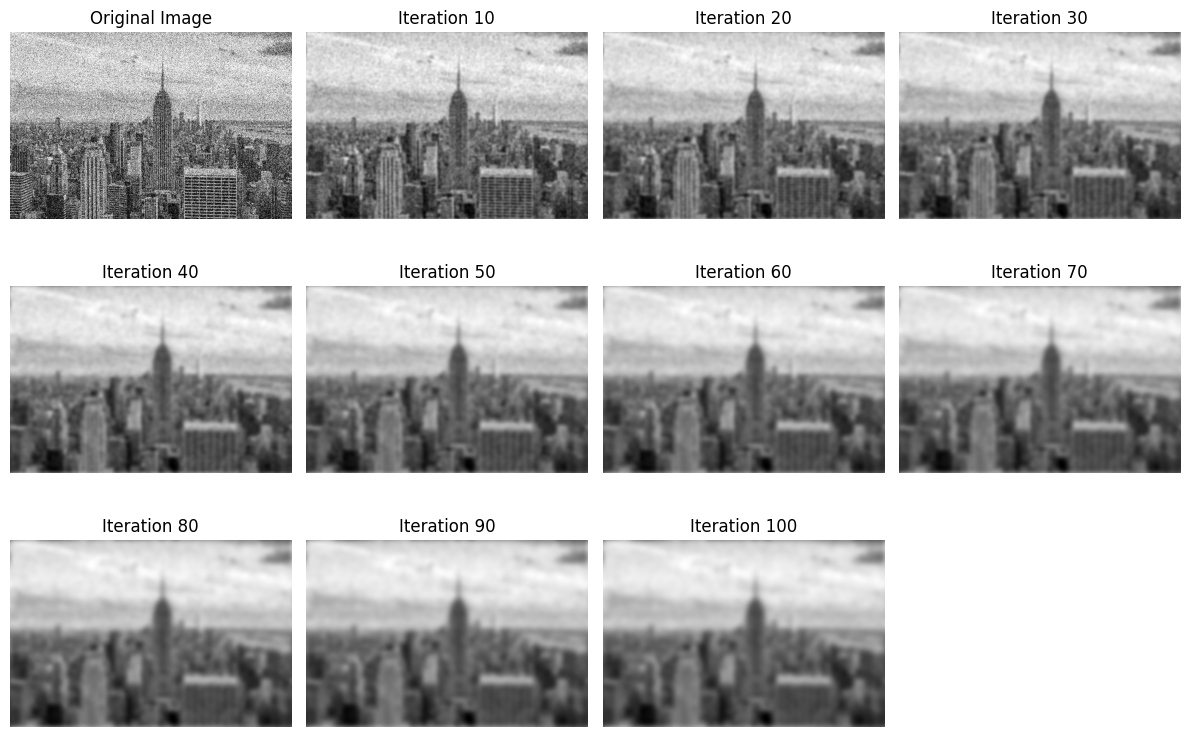

In [55]:
#Visualising the steps:

#Diffuse the image, visualize each step
def diffuse_visualize(img, lam=0.2, iterations=100):
    I = img.copy()

    #Creating figure to show each step
    plt.figure(figsize=(12, 8))

    #Adding noisy image
    plt.subplot(3, 4, 1)
    plt.imshow(I, cmap="gray")
    plt.title(f"Original Image")
    plt.axis("off")

    #Next plot index
    plot_idx = 2

    for i in range(1, iterations + 1):
        #Compute the Laplacian
        laplacian = (
            np.roll(I, 1, axis=0) +  #Down
            np.roll(I, -1, axis=0) + #Up
            np.roll(I, 1, axis=1) +  #Right
            np.roll(I, -1, axis=1) - #Left
            4 * I)

        #Update image
        I = I + lam * laplacian

        #Plot every 10th intermediate step
        if i % 10 == 0:
          plt.subplot(3, 4, plot_idx)
          plt.imshow(I, cmap="gray")
          plt.title(f"Iteration {i}")
          plt.axis("off")
          plot_idx += 1

    plt.tight_layout()
    plt.show()

#Running the function to visualize diffusion steps
diffuse_visualize(noisy_img, lam=0.2, iterations=100)

# Anisotropic diffusion: edge-preserving
In the context of image processing:

In image processing, edges refer to areas in the image where there is a sudden change in intensity. This often corresponds to important structures within the image, like objects.

Edge-preserving techniques aim to smooth or diffuse the image without blurring or removing these important boundaries, so the image is still perceivable.

For this we use the Perona-Malik equation, given by
\begin{align}
  \frac{\partial I}{\partial t} = \nabla \cdot \left(c(\|\nabla I\|)\nabla I\right).
\end{align}

Here, $c(\cdot)$ is the conductance function, which controls the strength of diffusion.
We will use an exponential function:
\begin{align}
  c(\|\nabla I\|) = \exp \left(-\left(\frac{\|\nabla I\|}{\kappa}\right)^2\right),
\end{align}
where $\kappa$ is a constant that controls the sensitivity to edges. The larger the value of
$\kappa$, the more the diffusion is allowed to spread across regions with slight intensity variations.

The exponential function ensures that at edges (where $\|\nabla I\|$ is large), the conductance is small so there is less diffusion. In flat regions (where $\|\nabla I\|$ is small), the conductance is high, allowing the diffusion to occur.

We solutions using a finite difference scheme as follows.

At each pixel, the updated value $I_n(x,y)$ is calucated using:
\begin{align}
  I_n(x,y) = I(x,y) + \lambda \left(\sum_{i,j \in \text{neighbours}} c(\|\nabla I\|) (I(x,y)-I(x+i,y+j) \right).
\end{align}

In [56]:
#Anisotropic diffusion: edge preserving

#Defining function to run anisotropic diffusion
def anisotrop_diffuse(img, kappa = 10, lam=0.2, iterations=100):
  I = img.copy()

  for _ in range(iterations):
    #Compute gradients
      grad_x = np.roll(I, -1, axis=1) - I  #Gradient in x-direction
      grad_y = np.roll(I, -1, axis=0) - I  #Gradient in y-direction

      #Compute conductance (edge-preserving factor)
      c_x = np.exp(-(grad_x / kappa) ** 2)  #Conductance in x-direction
      c_y = np.exp(-(grad_y / kappa) ** 2)  #Conductance in y-direction

      #Apply diffusion with the conductance
      I = I + lam * (np.roll(c_x, 1, axis=1) * grad_x + np.roll(c_y, 1, axis=0) * grad_y)

  return I

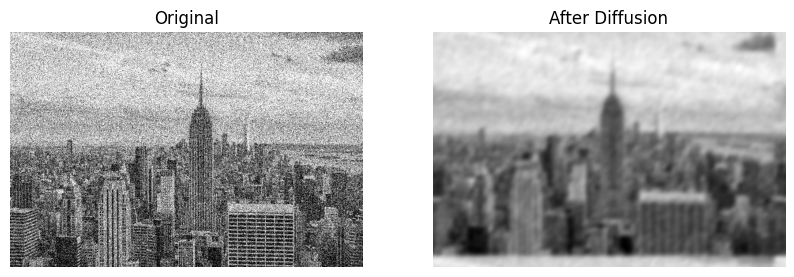

In [57]:
#Running diffusion
smoothed_anisotrop = anisotrop_diffuse(noisy_img, lam=0.2, iterations=100)

#Creating figure
plt.figure(figsize=(10,4))

#Adding noisy image
plt.subplot(1,2,1)
plt.imshow(noisy_img, cmap="gray")
plt.title("Original")
plt.axis("off")

#Adding smoothed image
plt.subplot(1,2,2)
plt.imshow(smoothed_anisotrop, cmap="gray")
plt.title("After Diffusion")
plt.axis("off")

plt.show()

### Visualising Anisotropic diffusion
Once again, we visualise each iteration to see just how the process works.

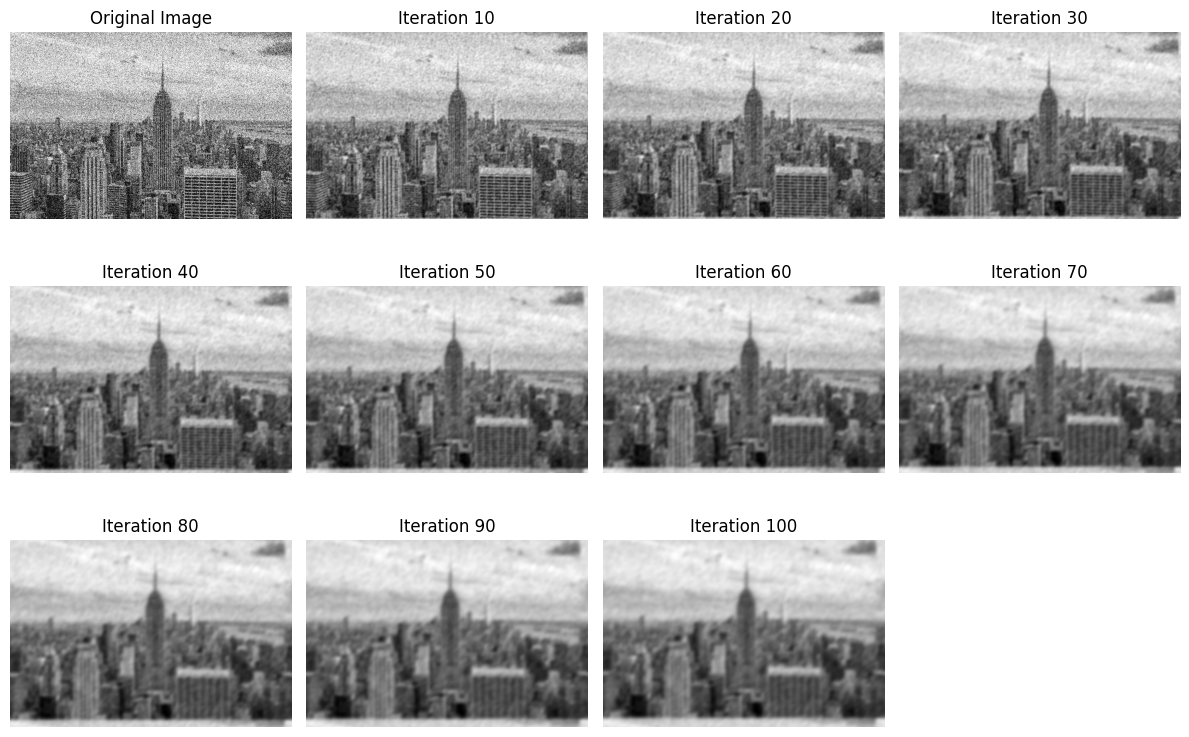

In [58]:
#Visualising anisotropic diffusion:

#Defining a function to visualise steps in anisotropic diffusion
def anisotropic_diffusion_visualise(img, kappa=10, lam=0.2, iterations=100):
    I = img.copy()

    #Create a figure for visualizing intermediate steps
    plt.figure(figsize=(12, 8))
    plt.subplot(3, 4, 1)
    plt.imshow(I, cmap="gray")
    plt.title("Original Image")
    plt.axis("off")

    #Next plot index
    plot_idx = 2

    #Perform the diffusion
    for i in range(1, iterations + 1):
        #Compute gradients
        grad_x = np.roll(I, -1, axis=1) - I  #Gradient in x-direction
        grad_y = np.roll(I, -1, axis=0) - I  #Gradient in y-direction

        #Compute conductance (edge-preserving factor)
        c_x = np.exp(-(grad_x / kappa) ** 2)  #Conductance in x-direction
        c_y = np.exp(-(grad_y / kappa) ** 2)  #Conductance in y-direction

        #Apply diffusion with the conductance
        I = I + lam * (np.roll(c_x, 1, axis=1) * grad_x + np.roll(c_y, 1, axis=0) * grad_y)

        #Plot every 10th intermediate step
        if i % 10 == 0:
          plt.subplot(3, 4, plot_idx)
          plt.imshow(I, cmap="gray")
          plt.title(f"Iteration {i}")
          plt.axis("off")
          plot_idx += 1

    plt.tight_layout()
    plt.show()

    return I

#Running the function to visualize intermediate steps
diffused_img = anisotropic_diffusion_visualise(noisy_img, kappa=10, lam=0.2,
                                               iterations=100)
